In [1]:
# import of modules
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import math
import seaborn as sns
from scipy import signal
%matplotlib inline

In [2]:
# setting of matplotlib
# font
plt.rcParams['font.family'] = 'Times New Roman'

# font of equation
plt.rcParams['mathtext.fontset'] = 'cm'

# direction of x and y-scales
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

# showing of minor x and y-scales
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

# showing of scales in all directions
plt.rcParams["xtick.top"] = True
plt.rcParams["xtick.bottom"] = True
plt.rcParams["ytick.left"] = True
plt.rcParams["ytick.right"] = True

# font size
plt.rcParams["font.size"] = 30

In [3]:
# High pass filter
def highpass_filter(x, samplerate, fp, fs, gpass, gstop):
    fn = samplerate / 2
    wp = fp / fn
    ws = fs / fn
    N, Wn = signal.buttord(wp, ws, gpass, gstop)
    b, a = signal.butter(N, Wn, "high")
    y = signal.filtfilt(b, a, x)
    return y

In [4]:
# Calculation of frequency
def calc_frequency(f_min, f_max, number):
    return np.linspace(f_min, f_max, number)

# Calculation of scale
def calc_scale(frequency, samplerate, cf):

    # frequency to analyze
    # cf: center frequency of mother wavelet
    scale = cf / frequency * samplerate
    
    return np.array(scale[::-1])

In [5]:
# Synchrosqueezed wavelet transform
def calc_swt(data, frequency, scales, samplerate):

    # Synchroaqueezed wavelet transform
    cwt = np.empty((np.size(scales),) + data.shape, dtype=np.complex64)
    swt = np.empty((np.size(scales),) + data.shape, dtype=np.complex64)
    cif = np.empty((np.size(scales),) + data.shape, dtype=np.complex64)

    for i, scale in enumerate(scales):

        # Calculation of mother wavelet
        length = int(16 * scale)

        # Range of mother wavelet in x=axis
        x = np.linspace(-8*scale, 8*scale, length)

        # Morlet wavelet
        # Center frequency
        fc = 1.0
        # Band width
        fb = 3.0
        mother_wavelet = 1 / np.sqrt(np.pi*fb) * np.exp(-(x/scale)**2/fb) * np.exp(2j*np.pi*fc*(x/scale))

        # Calculation of coefficients
        coef1 = 1 / np.sqrt(scale) * np.convolve(data, np.conj(mother_wavelet[::-1]))
        coef2 = 1 / np.sqrt(scale) * np.convolve(data, (x[::-1]/scale)*np.conj(mother_wavelet[::-1]))

        # Resize of cofficients (shape of CWT and SWT = (length of scale) × (length of data))
        d1 = (coef1.shape[-1] - data.shape[-1]) / 2
        coef1 = coef1[math.floor(d1):-math.ceil(d1)]
        d2 = (coef2.shape[-1] - data.shape[-1]) / 2
        coef2 = coef2[math.floor(d2):-math.ceil(d2)]

        # CWT
        cwt[i] = coef1

        # Candidate instantaneous frequency
        cif[i] = 2 * np.pi * fc / scale * samplerate  + (-1j) * 2 / fb / scale * samplerate * coef2 / coef1
        
    omega = 2 * np.pi * frequency[::-1]
    delta_omega = omega[0] - omega[1]

    scale_matrix = []
    delta_scale_matrix = []

    for i in range(len(scales)):
        scale_matrix.append([scales[i]] * len(data))
        if i < len(scales)-1:
            delta_scale_matrix.append([scales[i+1]-scales[i]] * len(data))
        else:
            delta_scale_matrix.append([scales[i]] * len(data))
            
    scale_matrix = np.array(scale_matrix)
    delta_scale_matrix = np.array(delta_scale_matrix)

    for i in range(len(omega)):
        matrix3 = np.full((len(scales), len(data)), delta_omega/2) - np.abs(np.abs(cif) - np.full((len(scales), len(data)), omega[i]))
        matrix3 = np.where(matrix3 >= 0, 1, 0)
        matrix = 1 / delta_omega * scale_matrix**(-3/2) * delta_scale_matrix * cwt * matrix3
        swt[i] = np.sum(matrix, axis=0)
    
    return np.abs(swt)

c:\Users\UekiLab\anaconda3\lib\site-packages\matplotlib\ticker.py:2937: RuntimeWarning: invalid value encountered in log10
  majorstep_no_exponent = 10 ** (np.log10(majorstep) % 1)


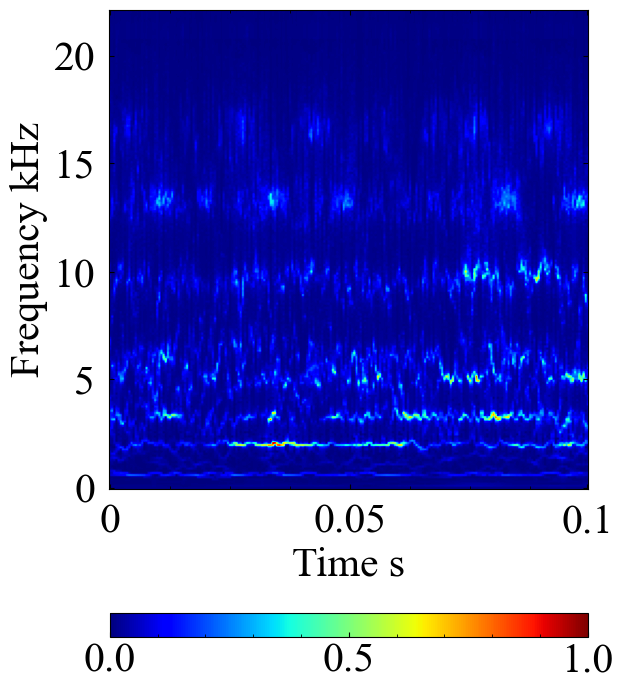

In [6]:
# choosing SNR (please unlock comment out)
SNR = 0
# SNR = -4
# SNR = -8
# SNR = -12
# SNR = -16
# SNR = -20

# choosing data type (please unlock comment out)
data_type = 'water_flow_125'
# data_type = 'gas-liquid_jet_0.15'
# data_type = 'gas-liquid_jet_0.17'
# data_type = 'gas-liquid_jet_0.20'

# filename
filename1 = '../01_Original_Data/water_flow_125.wav'
filename2 = '../01_Original_Data/' + data_type + '.wav'

# reading of wav file
data1, samplerate = sf.read(filename1)
data2, samplerate = sf.read(filename2)

# preprocessing by high pass filter
data1 = highpass_filter(data1[:2646000,0], samplerate, 1000, 900, 0.00001, 0.0001)
data2 = highpass_filter(data2[:2646000,0], samplerate, 1000, 900, 0.00001, 0.0001)

# amplify background noise according to SNR
data1_power = sum(data1**2) / len(data1)
data2_power = sum(data2**2) / len(data2)
data1 = data1 * np.sqrt((data2_power / 10 ** (SNR / 10)) / data1_power)

# normal sound -> water flow sound
# anomaly sound -> water flow sound + bubble jet flow sound
if data_type == 'water_flow_125':
    all_data = data1
else:
    all_data = data1 + data2

# segment length
data_length = 4410

# size of picture (224 pixel × 224 pixel)
number = 224

# sampling rate
samplerate = 44100

# minimum and maximum frequency to analyze
f_min, f_max = 100, samplerate/2

# frequency
frequency = calc_frequency(f_min, f_max, number)

# scale
scale = calc_scale(frequency, samplerate,1)

# extraction of segment and swt
i = 6
start = data_length * i
finish = data_length * (i + 1)
swt = calc_swt(all_data[start:finish], frequency, scale, samplerate)

# resize into number × number
# resize of cwt to make cwt divisible by number
swt = swt[:,:int(data_length - data_length % number)]
# matrix of compressed cwt
swt_comp = np.zeros((number, number))
# extract the maximum value in each region
interval = int((data_length - data_length % number) / number)
for j in range(number):
    for k in range(number):
        swt_comp[j][k] = np.max(swt[j, int(k*interval):int((k+1)*interval)])

# time axis
time_axis = np.linspace(0, 1/samplerate * (data_length - 1), number)
# frequency axis
frequency_axis = np.linspace(0, samplerate/2000, number)

# figure
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111)

# heatmap
im = ax.imshow(swt_comp/np.max(swt_comp), vmin=0, vmax=1, cmap='jet')

# x-label and y-label
ax.set_xlabel('Time s')
ax.set_ylabel('Frequency kHz')

# x-scales
x_label = [0, 0.05, 0.1]
x_position = [np.argmin(np.abs(d - time_axis)) for d in x_label]
plt.xticks(x_position, x_label)

# y-scales
y_label = [0, 5, 10, 15, 20]
y_position = [(224 - 1) - np.argmin(np.abs(d - frequency_axis)) for d in y_label]
plt.yticks(y_position, y_label)

# space between scale and plot area
ax.tick_params(pad=10)

# colorbar
plt.colorbar(im, ticks=[0, 0.5, 1.0], pad=0.175, shrink=0.525, orientation='horizontal')

plt.tight_layout()
plt.show()